In [21]:
!pip install yfinance lightgbm scikit-learn pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [22]:
# Step 2: Download historical stock data
import yfinance as yf
ticker = "AAPL"
data = yf.download(ticker, start="2018-01-01", end="2024-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [24]:
# Step 3: Flatten MultiIndex columns if present
import pandas as pd
if isinstance(data.columns, pd.MultiIndex):
    data.columns = ['_'.join([str(i) for i in col if i]) for col in data.columns]

In [25]:
# Step 4: Clean column names
data.columns = data.columns.astype(str)
data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace('[^A-Za-z0-9]+', '_', regex=True)

print("Cleaned columns:", data.columns.tolist())  # Debug


Cleaned columns: ['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL']


In [26]:
# Step 5: Dynamically find main OHLCV columns
def find_column(columns, keyword):
    for col in columns:
        if keyword.lower() in col.lower():
            return col
    return None

col_open = find_column(data.columns, 'open')
col_high = find_column(data.columns, 'high')
col_low = find_column(data.columns, 'low')
col_close = find_column(data.columns, 'close')
col_volume = find_column(data.columns, 'volume')

if not all([col_open, col_high, col_low, col_close, col_volume]):
    raise KeyError(f"Could not find all OHLCV columns. Found: {list(data.columns)}")

In [27]:
# Step 6: Feature engineering
data['Open_Close'] = data[col_open] - data[col_close]
data['High_Low'] = data[col_high] - data[col_low]
data['Volume_Change'] = data[col_volume].pct_change()
data['Close_Change'] = data[col_close].pct_change()

# Drop NA values
data.dropna(inplace=True)

In [28]:
# Step 7: Create target (next day's close)
data['Target'] = data[col_close].shift(-1)
data.dropna(inplace=True)

In [29]:
# Step 8: Select features
features = [col_open, col_high, col_low, col_close, col_volume,
            'Open_Close', 'High_Low', 'Volume_Change', 'Close_Change']

X = data[features]
y = data['Target']

In [31]:
# Step 9: Train-test split (time series, no shuffle)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [33]:
# Step 10: Train LightGBM model
import lightgbm as lgb
model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 1205, number of used features: 9
[LightGBM] [Info] Start training from score 93.593515


LGBMRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [34]:
# Step 11: Predict on test set
y_pred = model.predict(X_test)

In [37]:
# Step 12: Evaluate model
import numpy as np
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"LightGBM RMSE: {rmse:.4f}")

LightGBM RMSE: 8.5589


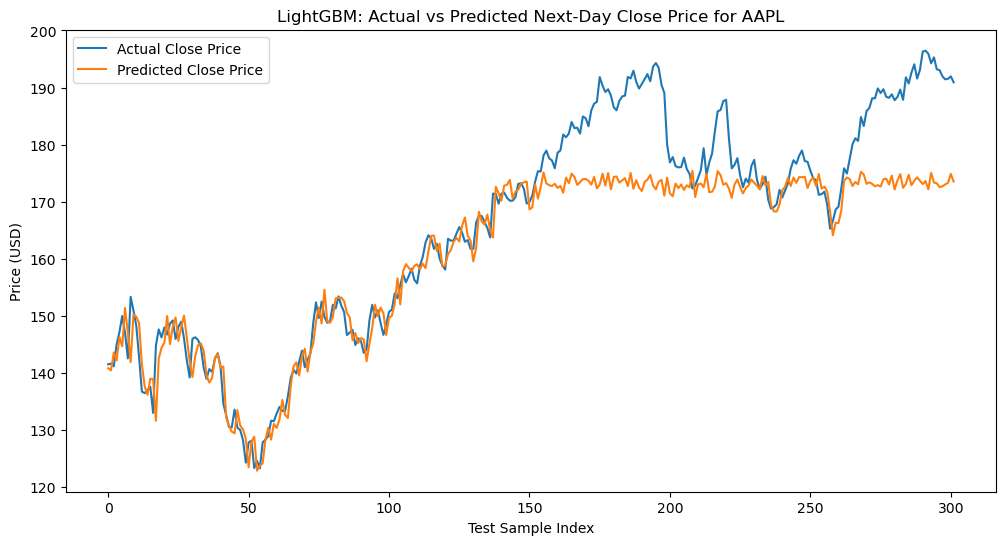

In [39]:
# Step 13: Plot Actual vs Predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Close Price')
plt.plot(y_pred, label='Predicted Close Price')
plt.title(f'LightGBM: Actual vs Predicted Next-Day Close Price for {ticker}')
plt.xlabel('Test Sample Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

<Figure size 1000x600 with 0 Axes>

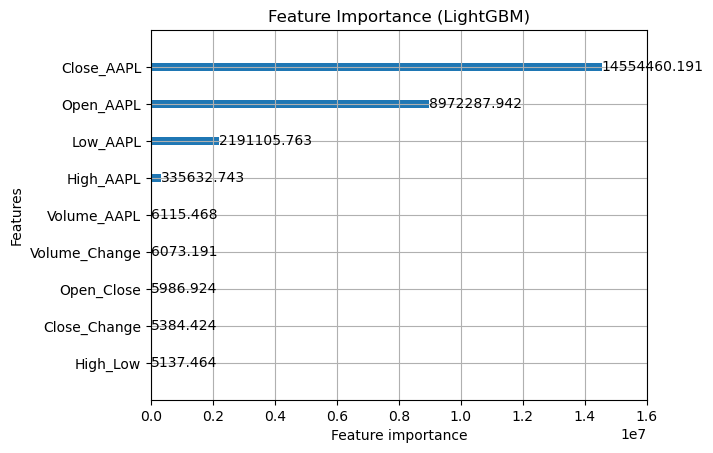

In [40]:
# Step 14: Feature Importance Plot
plt.figure(figsize=(10,6))
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title('Feature Importance (LightGBM)')
plt.show()

In [41]:
# Step 14: Predict next day's price
last_row = X.iloc[[-1]]  # last available row
next_day_price = model.predict(last_row)[0]
print(f"Predicted next-day close price: {next_day_price:.2f} USD")

Predicted next-day close price: 173.52 USD
